In [43]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [44]:
def Convolution(x, K, b, stride, padding, dilation):
    # x : (batch, C_in, H, W)
    # K : (C_out, C_in, kH, kW)
    # b : (C_out,)

    if padding > 0:
        x = np.pad(x, ((0,0), (0,0), (padding, padding), (padding, padding)), mode='constant')

    batch, C_in, H, W = x.shape
    C_out, _, kH, kW = K.shape

    eff_kH = kH + (kH - 1) * (dilation - 1)
    eff_kW = kW + (kW - 1) * (dilation - 1)

    out_H = (H - eff_kH) // stride + 1
    out_W = (W - eff_kW) // stride + 1

    out = np.zeros((batch, C_out, out_H, out_W))

    for co in range(C_out):
        for ci in range(C_in):
            for m in range(kH):
                for n in range(kW):
                    xi_start = m * dilation
                    xj_start = n * dilation
                    x_slice = x[:, ci,
                                xi_start : xi_start + out_H*stride : stride,
                                xj_start : xj_start + out_W*stride : stride]
                    out[:, co] += x_slice * K[co, ci, m, n]
        out[:, co] += b[co]

    return out

def Pooling(x, size, stride):
    batch, C, H, W = x.shape
    out_H = (H - size) // stride + 1
    out_W = (W - size) // stride + 1
    y = np.zeros((batch, C, out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            fenetre = x[:, :, i*stride:i*stride+size, j*stride:j*stride+size]
            y[:, :, i, j] = np.max(fenetre, axis=(2,3))
    return y

def ReLULayer(x):
  x = np.maximum(0, x)
  return(x)

def FullyConnectedLayer(W, x, b):
  j = W @ x + b
  return(j)

def softmax(x):
 exp_x = np.exp(x - np.max(x, axis=0, keepdims=True))
 sum_exp_x = np.sum(exp_x, axis=0, keepdims=True)
 softmax_x = exp_x / sum_exp_x
 return softmax_x

def Gradient_1(y_batch, y_pred):
 d = np.zeros((10, len(y_batch)))
 d[y_batch, np.arange(len(y_batch))] = 1
 gradient1 = y_pred - d
 return(gradient1)

def GradientConv2d(a_prev, W, gradient, stride=1):
    batch, C_in, H, Wid = a_prev.shape
    C_out, _, k, _ = W.shape
    _, _, H_out, W_out = gradient.shape

    gradient_b = np.sum(gradient, axis=(0, 2, 3)) / batch

    gradient_W = np.zeros_like(W)
    for co in range(C_out):
        for ci in range(C_in):
            for p in range(k):
                for q in range(k):
                    patch = a_prev[:, ci, p:p+H_out*stride:stride, q:q+W_out*stride:stride]
                    gradient_W[co, ci, p, q] = np.sum(patch * gradient[:, co, :, :]) / batch

    gradient_a_prev = np.zeros_like(a_prev)
    pad = k - 1
    gradient_padded = np.pad(gradient, ((0,0),(0,0),(pad,pad),(pad,pad)))
    W_flipped = W[:, :, ::-1, ::-1]
    for ci in range(C_in):
        for co in range(C_out):
            for i in range(H):
                for j in range(Wid):
                    patch = gradient_padded[:, co, i:i+k, j:j+k]
                    gradient_a_prev[:, ci, i, j] += np.sum(patch * W_flipped[co, ci], axis=(1,2))

    return(gradient_W, gradient_b, gradient_a_prev)


def GradientReshape(val_before_reshape, gradient):
    gradient = gradient.T.reshape(val_before_reshape)
    return gradient

def GradientPool(mask, gradient, pool_size=2):
    gradient_etale = np.repeat(np.repeat(gradient, pool_size, axis=-2), pool_size, axis=-1)
    return(mask * gradient_etale)

def GradientFClay(a, gradient, W):
  gradient_W = (gradient @ a.T) / batch_size
  gradient_b = np.mean(gradient, axis=1, keepdims=True)
  gradient_a_prev = W.T @ gradient
  return(gradient_W, gradient_b, gradient_a_prev)

def GradientReluOnly(z, gradient):
    return(gradient * (z > 0))

def init_conv(C_out, C_in, k):
    std = np.sqrt(2 / (C_in * k * k))
    W = np.random.randn(C_out, C_in, k, k) * std
    b = np.zeros(C_out)
    return W, b

W_conv2d_1, b_conv2d_1 = init_conv(32, 1, 5)
W_conv2d_2, b_conv2d_2 = init_conv(64, 32, 5)

W_fclay1 = np.random.randn(200, 256)* 0.1
b_fclay1 = np.zeros((200,1))

W_fclay2 = np.random.randn(10,200) * 0.1
b_fclay2 = np.zeros((10,1))

def maj_W(gradient_W, W, n):
  W = W - n*gradient_W
  return(W)

def maj_b(gradient_b, b, n):
  b = b - n*gradient_b
  return(b)

def Loss(y_pred, y_batch):
  batch_size = len(y_batch)
  v = y_pred[y_batch, np.arange(batch_size)]
  result = -np.log(v)
  return(np.mean(result))

LossStock = []

#foreward
# sortie de conv2d 1 et 2 = mask_before_conv
# sortie de relu 2 = val_before_reshape for gradient reshape
# x -> conv2d 1 -> pool 1 -> relu 1 -> conv2d 2 -> pool 2 -> relu 2 -> reshape -> fc 1 -> relu 3 -> fc 2 -> softmax -> y
#Backward
# x <- conv2d 1 <- pool 1 <- relu 1 <- conv2d 2 <- pool 2 <- relu 2 <- reshape <- fc 1 <- relu 3 <- fc 2 <- softmax <- y

Epoch 1 terminée
Epoch 2 terminée
Epoch 3 terminée


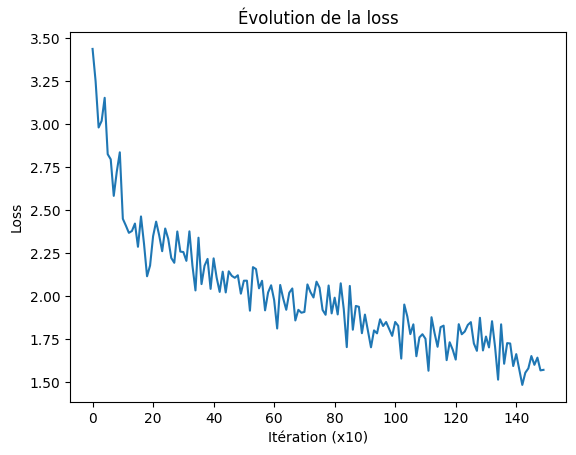

In [45]:
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]
n_epochs = 3
batch_size = 40
for epoch in range(n_epochs):
 for i in range(0, len(X_train_small), batch_size):
  x = X_train_small[i:i+batch_size].reshape(-1, 1, 28, 28) / 255
  y = y_train_small[i:i+batch_size]
  conv2d_1 = Convolution(x, W_conv2d_1, b_conv2d_1, 1, 0, 1)
  pool_1 = Pooling(conv2d_1, 3,3)
  relu_1 = ReLULayer(pool_1)
  conv2d_2 = Convolution(relu_1, W_conv2d_2, b_conv2d_2, 1, 0, 1)
  pool_2 = Pooling(conv2d_2, 2,2)
  relu_2 = ReLULayer(pool_2)
  reshape = relu_2.reshape(relu_2.shape[0], -1).T
  fclay_1 = FullyConnectedLayer(W_fclay1,reshape,b_fclay1)
  relu_3 = ReLULayer(fclay_1)
  fclay_2 = FullyConnectedLayer(W_fclay2,relu_3,b_fclay2)
  soft = softmax(fclay_2)
  y_pred = soft

  sortie_etale2 = np.repeat(np.repeat(pool_2, 2, axis=-2), 2, axis=-1)
  mask2 = (conv2d_2 == sortie_etale2).astype(float)
  sortie_etale1 = np.repeat(np.repeat(pool_1, 3, axis=-2), 3, axis=-1)
  mask1 = (conv2d_1 == sortie_etale1).astype(float)

  grad1 = Gradient_1(y, y_pred)
  grad2 = GradientFClay(relu_3, grad1, W_fclay2)
  grad3 = GradientReluOnly(fclay_1, grad2[2])
  grad4 = GradientFClay(reshape, grad3, W_fclay1)
  grad5 = GradientReshape(relu_2.shape, grad4[2])
  grad6 = GradientReluOnly(pool_2, grad5)
  grad7 = GradientPool(mask2, grad6, 2)
  grad8 = GradientConv2d(relu_1, W_conv2d_2, grad7, 1)
  grad9 = GradientReluOnly(pool_1, grad8[2])
  grad10 = GradientPool(mask1, grad9, 3)
  grad11 = GradientConv2d(x, W_conv2d_1, grad10 , 1)

  majW_FClay2 = maj_W(grad2[0],W_fclay2, 0.001)
  majb_FClay2 = maj_b(grad2[1],b_fclay2, 0.001)

  majW_FClay1 = maj_W(grad4[0],W_fclay1, 0.001)
  majb_FClay1 = maj_b(grad4[1],b_fclay1, 0.001)

  majW_Conv2 = maj_W(grad8[0],W_conv2d_2, 0.001)
  majb_Conv2 = maj_b(grad8[1],b_conv2d_2, 0.001)

  majW_Conv1 = maj_W(grad11[0],W_conv2d_1, 0.001)
  majb_Conv1 = maj_b(grad11[1],b_conv2d_1, 0.001)

  W_conv2d_1 = majW_Conv1
  b_conv2d_1 = majb_Conv1

  W_conv2d_2 = majW_Conv2
  b_conv2d_2 = majb_Conv2

  W_fclay1 = majW_FClay1
  b_fclay1 = majb_FClay1

  W_fclay2 = majW_FClay2
  b_fclay2 = majb_FClay2

  if i % 10 == 0:
    L = Loss(y_pred,y)
    LossStock.append(L)
 print(f"Epoch {epoch+1} terminée")

plt.plot(LossStock)
plt.xlabel("Itération (x10)")
plt.ylabel("Loss")
plt.title("Évolution de la loss")
plt.show()


